<a href="https://colab.research.google.com/github/EcTrailblazers/python-data-projects/blob/main/07_niti_governance_index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Raw indicators across districts:
# 1. Institutional_Deliveries_% (Positive indicator: Higher is better)
# 2. School_Dropout_Rate_% (Negative indicator: Lower is better)
# 3. Piped_Water_Access_% (Positive indicator: Higher is better)
# 4. Underweight_Children_% (Negative indicator: Lower is better)

raw_district_data = """District,State,Institutional_Deliveries_%,School_Dropout_Rate_%,Piped_Water_Access_%,Underweight_Children_%
Kupwara,Jammu and Kashmir,88.4,12.5,65.0,24.1
Dahod,Gujarat,74.2,18.4,52.1,38.5
Namsai,Arunachal Pradesh,68.0,22.1,44.0,31.2
Chandauli,Uttar Pradesh,79.5,14.8,58.2,34.0
Mewat,Haryana,62.1,28.6,41.5,42.1
Baksa,Assam,71.3,19.2,49.0,33.4
Kandhamal,Odisha,65.4,24.5,38.0,41.0
Vidisha,Madhya Pradesh,82.0,11.0,68.4,28.3
Ramanathapuram,Tamil Nadu,96.5,4.2,88.0,18.5
Raichur,Karnataka,76.8,16.5,61.2,32.8
"""

with open("district_governance_data.csv", "w") as f:
    f.write(raw_district_data.strip())

print("district_governance_data.csv created successfully.")

district_governance_data.csv created successfully.


In [2]:
df_districts = pd.read_csv("district_governance_data.csv")


# Normalization helper function
def min_max_scale(series, positive=True):
    s_min = series.min()
    s_max = series.max()
    if positive:
        return ((series - s_min) / (s_max - s_min)) * 100
    else:
        return ((s_max - series) / (s_max - s_min)) * 100


# Apply directional normalization
df_districts["Score_Deliveries"] = min_max_scale(
    df_districts["Institutional_Deliveries_%"], positive=True
)
df_districts["Score_Dropout"] = min_max_scale(
    df_districts["School_Dropout_Rate_%"], positive=False
)
df_districts["Score_Water"] = min_max_scale(
    df_districts["Piped_Water_Access_%"], positive=True
)
df_districts["Score_Nutrition"] = min_max_scale(
    df_districts["Underweight_Children_%"], positive=False
)

print("--- Normalized Indicator Scores (0 - 100 Scale) ---")
print(
    df_districts[
        [
            "District",
            "Score_Deliveries",
            "Score_Dropout",
            "Score_Water",
            "Score_Nutrition",
        ]
    ].round(1)
)

--- Normalized Indicator Scores (0 - 100 Scale) ---
         District  Score_Deliveries  Score_Dropout  Score_Water  \
0         Kupwara              76.5           66.0         54.0   
1           Dahod              35.2           41.8         28.2   
2          Namsai              17.2           26.6         12.0   
3       Chandauli              50.6           56.6         40.4   
4           Mewat               0.0            0.0          7.0   
5           Baksa              26.7           38.5         22.0   
6       Kandhamal               9.6           16.8          0.0   
7         Vidisha              57.8           72.1         60.8   
8  Ramanathapuram             100.0          100.0        100.0   
9         Raichur              42.7           49.6         46.4   

   Score_Nutrition  
0             76.3  
1             15.3  
2             46.2  
3             34.3  
4              0.0  
5             36.9  
6              4.7  
7             58.5  
8            100.0  


In [3]:
# 1. Compute weighted composite score
df_districts["Health_Score"] = (
    df_districts["Score_Deliveries"] * 0.5
    + df_districts["Score_Nutrition"] * 0.5
)
df_districts["Education_Score"] = df_districts["Score_Dropout"]
df_districts["Infra_Score"] = df_districts["Score_Water"]

df_districts["Composite_Index"] = (
    df_districts["Health_Score"] * 0.50
    + df_districts["Education_Score"] * 0.25
    + df_districts["Infra_Score"] * 0.25
)

# 2. Assign NITI Aayog category tiers
conditions = [
    df_districts["Composite_Index"] >= 100,
    df_districts["Composite_Index"] >= 65,
    df_districts["Composite_Index"] >= 50,
]
choices = ["Achiever", "Front Runner", "Performer"]
df_districts["Category"] = np.select(conditions, choices, default="Aspirant")

# 3. Sort by rank
df_districts = df_districts.sort_values(
    by="Composite_Index", ascending=False
).reset_index(drop=True)
df_districts["Rank"] = df_districts.index + 1

print("--- Composite Governance Leaderboard ---")
print(
    df_districts[
        ["Rank", "District", "State", "Composite_Index", "Category"]
    ].round(2)
)

--- Composite Governance Leaderboard ---
   Rank        District              State  Composite_Index      Category
0     1  Ramanathapuram         Tamil Nadu           100.00      Achiever
1     2         Kupwara  Jammu and Kashmir            68.18  Front Runner
2     3         Vidisha     Madhya Pradesh            62.31     Performer
3     4       Chandauli      Uttar Pradesh            45.47      Aspirant
4     5         Raichur          Karnataka            44.53      Aspirant
5     6           Baksa              Assam            31.03      Aspirant
6     7           Dahod            Gujarat            30.11      Aspirant
7     8          Namsai  Arunachal Pradesh            25.49      Aspirant
8     9       Kandhamal             Odisha             7.76      Aspirant
9    10           Mewat            Haryana             1.75      Aspirant


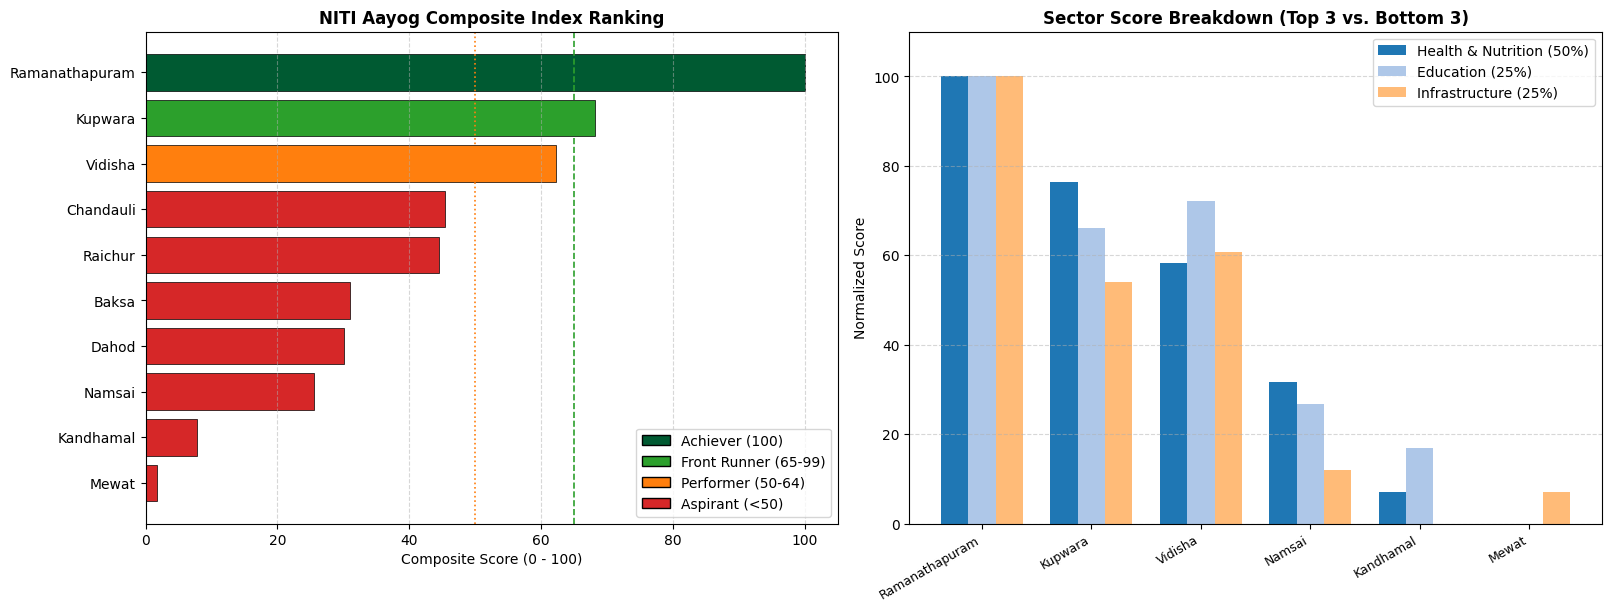

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), layout="constrained")

# --- Chart 1: Ranked Composite Scores with Tier Coloring ---
sorted_df = df_districts.sort_values(by="Composite_Index", ascending=True)

tier_palette = {
    "Achiever": "#005a32",  # Deep green for top tier
    "Front Runner": "#2ca02c",
    "Performer": "#ff7f0e",
    "Aspirant": "#d62728",
}
colors = [tier_palette[cat] for cat in sorted_df["Category"]]

ax1.barh(
    sorted_df["District"],
    sorted_df["Composite_Index"],
    color=colors,
    edgecolor="black",
    linewidth=0.5,
)
ax1.axvline(
    65.0,
    color="#2ca02c",
    linestyle="--",
    linewidth=1.2,
    label="Front Runner Cutoff (65)",
)
ax1.axvline(
    50.0,
    color="#ff7f0e",
    linestyle=":",
    linewidth=1.2,
    label="Performer Cutoff (50)",
)

ax1.set_title("NITI Aayog Composite Index Ranking", fontsize=12, weight="bold")
ax1.set_xlabel("Composite Score (0 - 100)")
ax1.set_xlim(0, 105)
ax1.grid(axis="x", linestyle="--", alpha=0.5)

legend_handles = [
    mpatches.Patch(
        facecolor="#005a32", edgecolor="black", label="Achiever (100)"
    ),
    mpatches.Patch(
        facecolor="#2ca02c", edgecolor="black", label="Front Runner (65-99)"
    ),
    mpatches.Patch(
        facecolor="#ff7f0e", edgecolor="black", label="Performer (50-64)"
    ),
    mpatches.Patch(
        facecolor="#d62728", edgecolor="black", label="Aspirant (<50)"
    ),
]
ax1.legend(handles=legend_handles, loc="lower right")

# --- Chart 2: Sector Score Breakdown for Top vs Bottom Districts ---
comparison_districts = pd.concat([df_districts.head(3), df_districts.tail(3)])
x = np.arange(len(comparison_districts))
width = 0.25

ax2.bar(
    x - width,
    comparison_districts["Health_Score"],
    width,
    label="Health & Nutrition (50%)",
    color="#1f77b4",
)
ax2.bar(
    x,
    comparison_districts["Education_Score"],
    width,
    label="Education (25%)",
    color="#aec7e8",
)
ax2.bar(
    x + width,
    comparison_districts["Infra_Score"],
    width,
    label="Infrastructure (25%)",
    color="#ffbb78",
)

ax2.set_xticks(x)
ax2.set_xticklabels(
    comparison_districts["District"], rotation=30, ha="right", fontsize=9
)
ax2.set_title(
    "Sector Score Breakdown (Top 3 vs. Bottom 3)", fontsize=12, weight="bold"
)
ax2.set_ylabel("Normalized Score")
ax2.set_ylim(0, 110)
ax2.grid(axis="y", linestyle="--", alpha=0.5)
ax2.legend(loc="upper right")

plt.show()